In [7]:
import pickle
import numpy as np
import matplotlib.pyplot as plt
from ITIS_Model_funcs import get_nominal_param,OLS_res,ITIS


In [8]:
param_log,IC = get_nominal_param()
IC = [ 2.0,          0.,          0.14759607,  0.,         13.75484703,  3.13344442, 15.73028492,  1.38649737]

D = '3'         # '1' for ACTH + Cort,
                # '2' for ACTH + Cort + TNF-a
                # '3' for ACTH + Cort + TNF-a + IL10
dpoints = '2'   # '1' for 25, '2' for 13

if D == '1':
    output_ids = [6,7]
    param_ids = [33, 12, 36, 32, 43, 39, 16, 7, 31, 37, 8, 15, 9, 28, 14]
elif D == '2':
    output_ids = [3,6,7]
    param_ids = [12, 33, 16, 7, 36, 43, 15, 39, 32, 8, 31, 14, 9, 1, 34]
elif D == '3':
    output_ids = [3,4,6,7]
    param_ids =[12, 33, 7, 36, 16, 43, 15, 39, 32, 8, 9, 31, 21, 14, 10, 34]


with open('Multistart_results\\OLSMultistart_nonoise_' + D + dpoints + '.pkl', 'rb') as f:
    results = pickle.load(f)
# with open('Multistart_incVar\\OLSMultistart_' + D + dpoints + '.pkl', 'rb') as f:
#     results = pickle.load(f)

t_data = results['t_data']
y_data = results['y_data']
param_opt = results['param_opt']
opt_cost = results['opt_cost']
dt = .05
tfinal = np.arange(0,24+dt,dt)
opt_solutions = results['opt_solutions']
#var = results['var']
true_sol = results['true_sol']
##SENSITIVITY ANALYSIS
h = 1e-6  #amount to perturb parameters
n_param = len(param_log)
n_states = len(output_ids)

S = np.zeros((n_param, len(t_data) * n_states)) ##Initialize shape of sensitivity matrix.

for i in range(n_param):  #calculate the relative residual sensitivity to each 45 parameters

        param_in = param_log[i]
        param_delta = param_in + h
##RIGHT NOW THIS IS BEING CALCULATED WITH NOISELESS DATA
        S[i, :] = ((1 / h) * (OLS_res(param_delta, y_data, t_data, i, output_ids, param_log, IC)
                                            - OLS_res(param_in, y_data, t_data, i, output_ids, param_log, IC)))

In [9]:

param_titles = ['d1',
'k1','k2','h1','h2','h3','d2',
'k3','k4','h4','d3',
'h5','h6','k5','k6','h7','d4',
'b1','k7','h8','k8','h9','d5','h10',
'b2','k9','k10','k11','d6',
'k12','k13','k14','h11','d7',
'k15','k16','d8',
'alpha', 'k', 'beta', 'L', 'eps', 'delta', 'T', 'Nc']

circadian_param = ['alpha', 'k', 'beta', 'L', 'eps', 'delta', 'T', 'Nc'] #exclude?

cond = 0
unid = []
p_indices = [param_titles.index(param_sorted[0])]
for i in range(1,len(rank_cut)):
    p_indices.append(param_titles.index(param_sorted[i]))
    S_opt = S[p_indices,:].copy()
    F_opt = S_opt@S_opt.T
    cond = np.linalg.cond(F_opt)
    if cond > 1e+6:
        unid.append(p_indices.pop())
        print("Removed: ", unid[-1])


S_opt = S[p_indices,:].copy()
F_opt = S_opt@S_opt.T
C_opt = np.linalg.inv(F_opt)
selected = [param_titles[i] for i in p_indices]
print("Design : ", D + dpoints)
print("Number of selected parameters:", len(p_indices))
print("Selected Parameters: ",  selected)
print(p_indices)
print("Excluded Parameters: ", [param_titles[i] for i in unid])
print("Condition Number of F:", np.linalg.cond(F_opt))
print("Diagonals of C:", np.diag(C_opt))

Design :  32
Number of selected parameters: 16
Selected Parameters:  ['h6', 'd7', 'k3', 'd8', 'd4', 'T', 'h7', 'beta', 'h11', 'k4', 'h4', 'k14', 'h9', 'k6', 'd3', 'k15']
[12, 33, 7, 36, 16, 43, 15, 39, 32, 8, 9, 31, 21, 14, 10, 34]
Excluded Parameters:  []
Condition Number of F: 11953.795746045116
Diagonals of C: [0.19510513 0.22827239 0.18506776 0.48511877 0.51252179 0.53480163
 0.1962738  2.29638398 0.20991786 0.21570837 0.61363941 0.14695226
 0.03365302 1.39143883 0.09685494 0.25256615]


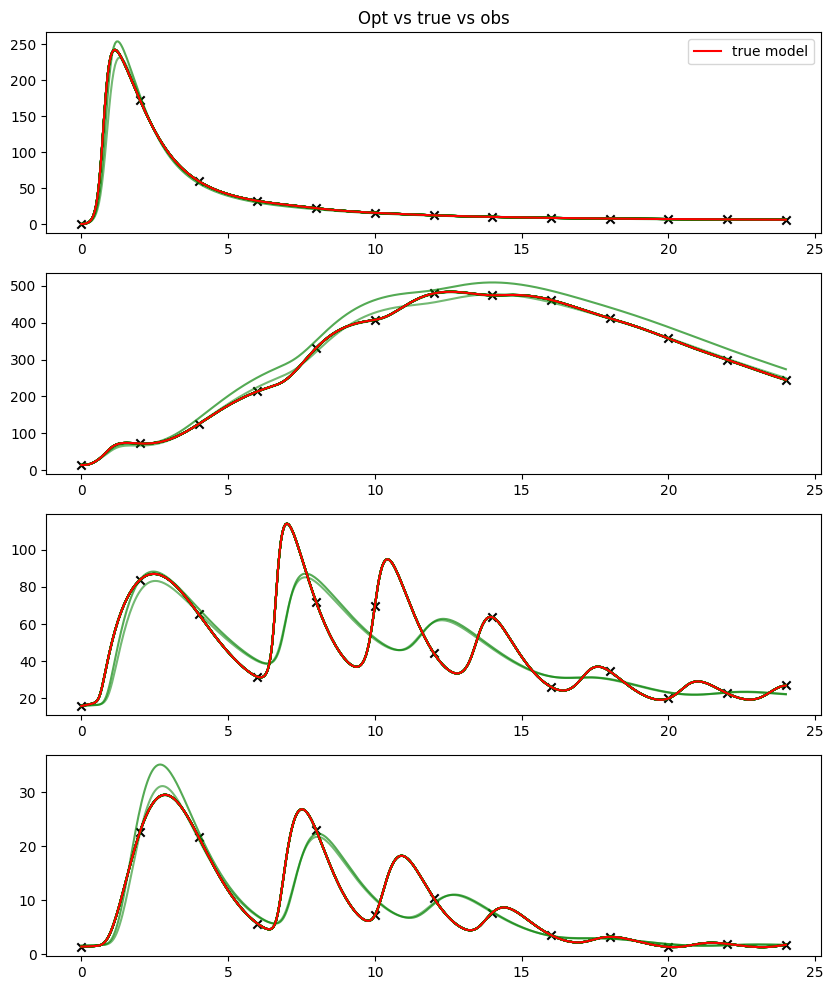

In [10]:

plt.figure(figsize = (10,3*len(output_ids),))
for i in range(len(output_ids)):
    a = 1.0
    if i == 1:
        plt.title('Opt vs true vs obs')
        plt.legend()
    plt.subplot(len(output_ids),1,i+1)
    plt.scatter(t_data,y_data[:,i],marker='x',color='k')
    for j in range(20):
        plt.plot(tfinal,opt_solutions[j,:,i].T, color = 'g', alpha = a)
        a -= .03
    plt.plot(tfinal,true_sol[:,output_ids[i]],color='r',label='true model')
plt.savefig("FIGS\\Multistart_modelsols_nonoise" + D + dpoints + ".png")
plt.show()

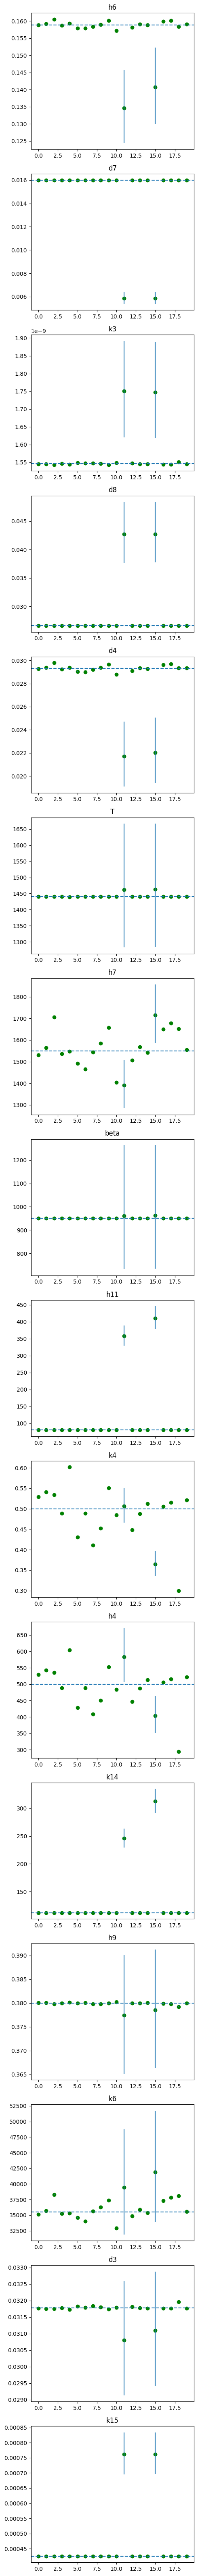

In [11]:
##  ADD NOISE
##Calculating CIS
from scipy import stats
##Calculate standard errors


##initialize container for bounds
alpha = 0.05
t_value = stats.t.ppf(1-alpha, len(t_data) * len(output_ids) - len(p_indices))

plt.figure(figsize = (5, 4*len(p_indices)))
for i in range(len(param_sorted)):
    CI = np.zeros((20,2))
    plt.subplot(len(p_indices), 1, i+1)
    for j in range(20):
        var_est = (1/(len(t_data) * len(output_ids) - len(p_indices))) * opt_cost[j]
        SE = np.sqrt(var_est * np.diag(C_opt))

        CI[j,0] = param_opt[j][i] - t_value * SE[i]
        CI[j,1] = param_opt[j][i] + t_value * SE[i]
        plt.vlines(x = j, ymin = np.exp(CI[j,0]), ymax = np.exp(CI[j,1]))
    #plt.ylim(np.exp(param_log[p_indices[i]] - param_log[p_indices[i]]* .1), np.exp(param_log[p_indices[i]] + param_log[p_indices[i]]* .1))
    plt.axhline(np.exp(param_log[p_indices[i]]), linestyle = '--')
    plt.scatter(range(20), np.exp(param_opt[:,i]), marker = 'o', color = 'g')
    plt.title(param_titles[p_indices[i]])
plt.tight_layout()
plt.savefig('FIGS\\post_opt_CIS_nonoise' + D + dpoints + '.png')
plt.show()

        #print(CI[i,0], param_opt[0][i], CI [i,1])
        #print(np.exp(CI[i,0]), np.exp(param_log[p_indices[i]]), np.exp(CI [i,1]))
     #print(np.exp(CI[i,0])/np.exp(param_log[p_indices[i]])-1, 0, np.exp(CI [i,1])/np.exp(param_log[p_indices[i]])-1)
##

##HOW DOES LOG SCALE AFFECT OUTCOME?